In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
str_variant = 'noPTI_noDown_model1'

Project: 20231010-gen-xii


### Output directory

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [4]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get feature names

In [5]:
list_str_model = [
    '01_ad',
    '02_pricing_pd',
    '03_pricing_lgd',
]
list_cols_all = []
for str_model in tqdm(list_str_model):
    # get list of features
    str_filename = 'df_cols_in_model.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
    list_cols = list(pd.read_csv(str_uri)['feature'])
    # add to list_cols_all
    list_cols_all.extend(list_cols)
# rm dups
list_cols_all = list(dict.fromkeys(list_cols_all))

# make df
df_cols = pd.DataFrame({'feature': list_cols_all})

# show
df_cols

  0%|          | 0/3 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:279: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
100%|██████████| 3/3 [00:00<00:00,  7.43it/s]


,feature
0,bankruptcycount24month__ln
1,inquiryshortterm12month__ln
2,re01s__tu
3,bankruptcystatus__ln
4,bankruptcytimenewest__ln
...,...
313,rev201__tu
314,g216s__tu
315,linka005__tu
316,fr02s__tu


### Import data dictionary

In [6]:
str_filename = 'Data_Dictionary.xlsx'
str_local_path = f'./input/{str_filename}'
df_description = pd.read_excel(str_local_path)

# lower column name
df_description['col'] = df_description['Column Name'].str.lower()

# map table to suffix
dict_map = {
    'Credit Vision (TU Accept)': '__tu',
    'Factor Trust (TU CVLINK)': '__tu', 
    'LN': '__ln',
    'Application': '__app', 
    'Debt': '__debt', 
    'Income': '__income',
}
df_description['suffix'] = df_description['Table'].map(dict_map)

# create feature
df_description['feature'] = df_description['col'] + df_description['suffix']

# subset
list_cols = ['feature', 'Description']
df_description = df_description[list_cols]

# show
df_description

,feature,Description
0,uniqueid__app,Unique ID
1,bigaccountid__app,Account ID
2,bigdebtorid__app,Debtor/Codebtor ID
3,bitdebtor__app,Debtor or Codebtor
4,strcity__app,City
...,...,...
2110,alert7__ln,"Regulatory, bankruptcy, or scoring alert"
2111,alert8__ln,"Regulatory, bankruptcy, or scoring alert"
2112,alert9__ln,"Regulatory, bankruptcy, or scoring alert"
2113,alert10__ln,"Regulatory, bankruptcy, or scoring alert"


### Join

In [7]:
df = pd.merge(
    left=df_cols,
    right=df_description,
    on='feature',
    how='left'
)
# show
df

,feature,Description
0,bankruptcycount24month__ln,Total unique bankruptcy case filings on file s...
1,inquiryshortterm12month__ln,Indicates subject has one or more LexisNexis p...
2,re01s__tu,Number of revolving trades
3,bankruptcystatus__ln,Indicates status of most recent bankruptcy fil...
4,bankruptcytimenewest__ln,Time (in months) since most recent bankruptcy ...
...,...,...
313,rev201__tu,Total Payment Ratio for Revolving accounts ove...
314,g216s__tu,Number of trades with a delinquency of 90 or m...
315,linka005__tu,Average number of checks ordered in the last 3...
316,fr02s__tu,Number of open finance revolving trades


In [8]:
# make into dictionary
dict_descriptions = dict(zip(df['feature'], df['Description']))
print(f'Features with no description from the data dictionary:')
a = 1
for key, val in dict_descriptions.items():
    if pd.isnull(val):
        print(f'{a} - {key}')
        a += 1
    else:
        pass

Features with no description from the data dictionary:
1 - fltgrossmonthly__income_sum
2 - fltgrossmonthly__income_count
3 - intopenbktype__app
4 - bankruptcycount__ln
5 - vehiclemake__app
6 - fltadvance__app
7 - ENG-vehicle_age
8 - bitgap__app
9 - addrcurrentdwelltype__ln
10 - addrcurrentsubjectowned__ln
11 - addrpreviouslengthofres__ln
12 - ENG-loan_to_value
13 - miles_odometer__app
14 - addrpreviousdwelltype__ln


In [9]:
# make dictionary for those features with NaN
dict_map = {
    'fltgrossmonthly__income_sum': 'Total income',
    'fltgrossmonthly__income_count': 'Total income sources (max = 2)',
    'bankruptcycount__ln': 'Number of bankruptcies',
    'intopenbktype__app': 'BK Type',
    'pti__app': 'Payment to income',
    'payment__app': 'Payment',
    'dti__app': 'Debt to income',
    'fltadvance__app': 'Advance',
    'ENG-vehicle_age': 'Age of vehicle (years)',
    'ENG-loan_to_value': 'Loan to value',
    'vehiclemake__app': 'Vehicle make',
    'bitnew__app': 'New vehicle tag',
    'strvehicletype__app': 'Vehicle type',
    'addrpreviousdwelltype__ln': 'Previous dwelling type',
    'ENG-applicationdate__app_month': 'Application month',
    'ENG-dealership_age': 'Dealership age',
    'bitgap__app': 'Gap tag',
    'bookvalue__app': 'Book value',
    'miles_odometer__app': 'Miles on vehicle',
    'ENG-applicationdate__app_quarter': 'Application quarter',
    'addrcurrentdwelltype__ln': 'Current dwelling type',
    'addrpreviouslengthofres__ln': 'Length of residency in previous residence',
    'addrcurrentsubjectowned__ln': 'Subject owns current address',
    'addrcurrentlengthofres__ln': 'Length of residency at current residence',
    'phoneinputmobile__ln': 'Phone on file is mobile',
    'addrprevioussubjectowned__ln': 'Subject owned previous address',
    'amtfinanced__app': 'Amount financed',
    'ENG-payment_to_income': 'Payment to income',
    'intscore__ln': 'LN score',
    'fltapproveddowntotal__app': 'Total down',
}
# replace
for key, val in dict_descriptions.items():
    # assign
    try:
        dict_descriptions[key] = dict_map[key]
    except KeyError:
        pass

# make df
df_descriptions = pd.DataFrame({
    'feature': list(dict_descriptions.keys()),
    'description': list(dict_descriptions.values()),
})

# show
df_descriptions

,feature,description
0,bankruptcycount24month__ln,Total unique bankruptcy case filings on file s...
1,inquiryshortterm12month__ln,Indicates subject has one or more LexisNexis p...
2,re01s__tu,Number of revolving trades
3,bankruptcystatus__ln,Indicates status of most recent bankruptcy fil...
4,bankruptcytimenewest__ln,Time (in months) since most recent bankruptcy ...
...,...,...
313,rev201__tu,Total Payment Ratio for Revolving accounts ove...
314,g216s__tu,Number of trades with a delinquency of 90 or m...
315,linka005__tu,Average number of checks ordered in the last 3...
316,fr02s__tu,Number of open finance revolving trades


### Show NaNs

In [10]:
df_nan = df_descriptions[pd.isnull(df_descriptions['description'])]

# show
df_nan

,feature,description


### Tag features

In [11]:
list_str_model = [
    '01_ad',
    '02_pricing_pd',
    '03_pricing_lgd',
]
dict_list_cols = {}
list_cols_all = []
for str_model in tqdm(list_str_model):
    # get list of features
    str_filename = 'df_cols_in_model.csv'
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
    list_cols = list(pd.read_csv(str_uri)['feature'])
    # assign
    dict_list_cols[str_model] = list_cols
    # extend
    list_cols_all.extend(list_cols)
# rm dups
list_cols_all = list(dict.fromkeys(list_cols_all))
# create df
df = pd.DataFrame({'feature': list_cols_all})
# create tags
for key, val in dict_list_cols.items():
    df[key] = df['feature'].apply(
        lambda x: 1 if x in val else 0,
    )
# sum the tags
list_cols = list(dict_list_cols.keys())
df['Sum'] = df[list_cols].sum(axis=1)
# subset
df = df[df['Sum'] > 0]
# sort
df.sort_values(by='Sum', ascending=False, inplace=True)

# ENG- tag
df['Eng'] = df['feature'].apply(
    lambda x: 1 if 'ENG-' in x else 0,
)

# __app tag
df['App'] = df['feature'].apply(
    lambda x: 1 if '__app' in x else 0,
)

# rename
dict_rename = {
    '01_ad': 'AD',
    '02_pricing_pd': 'PD',
    '03_pricing_lgd': 'LGD',
}
df.rename(columns=dict_rename, inplace=True)

# get description
df['description'] = df['feature'].map(dict_descriptions)

# save
str_filename = 'df_descriptions.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
df.to_csv(str_local_path, index=False)

# # show
df

100%|██████████| 3/3 [00:00<00:00, 26.03it/s]


,feature,AD,PD,LGD,Sum,Eng,App,description
129,at57s__tu,1,1,1,3,0,0,Total past due amount of open trades verified ...
43,bkc321__tu,1,1,1,3,0,0,Min Total Open-to-Buy for Bankcard accounts ov...
194,rev205__tu,1,1,1,3,0,0,Total Payment Ratio for Revolving accounts ove...
75,linka017__tu,1,1,1,3,0,0,Number of checking account closures for cause ...
10,dealerstate__app,1,1,1,3,0,1,Dealer State
...,...,...,...,...,...,...,...,...
150,g242s__tu,1,0,0,1,0,0,Number of inquiries (includes duplicates) in p...
151,cv02__tu,1,0,0,1,0,0,Months since most recent foreclosure occurrence
152,sourcenonderogcount12month__ln,1,0,0,1,0,0,Total non-derogatory source types on file for ...
153,assetproppurchasetimeoldest__ln,1,0,0,1,0,0,Time (in months) since earliest recorded real ...


### See proportion in each sum

In [12]:
ser_freq = df['Sum'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['sum','prop']
df_freq

,sum,prop
0,1,0.773585
1,2,0.198113
2,3,0.028302


### Plot sum of each model

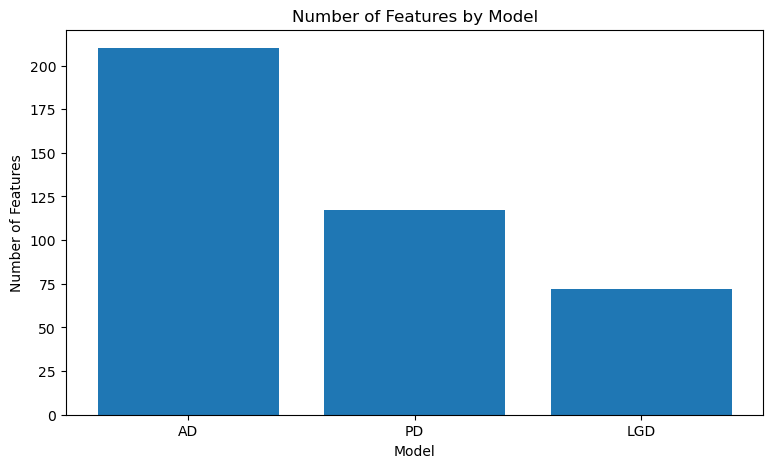

In [13]:
list_str_model = [
    'AD',
    'PD',
    'LGD',
]
list_dict_row = []
for str_model in list_str_model:
    flt_sum = df[str_model].sum()
    dict_row = {
        'model': str_model,
        'sum': flt_sum,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Number of Features by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Number of Features')
ax.bar(df_tmp['model'], df_tmp['sum'])
plt.show()

### Get master list

In [14]:
list_str_dirname = os.listdir(str_dirname_output)
list_str_dirname = [str_dirname for str_dirname in list_str_dirname if '.' not in str_dirname]
list_str_dirname = [str_dirname for str_dirname in list_str_dirname if 'noPTI' in str_dirname]
print(f'There are {len(list_str_dirname)} model variants:')
for a, str_dirname in enumerate(list_str_dirname):
    print(f'{a+1} - {str_dirname}')

There are 3 model variants:
1 - noPTI_noDown_model1
2 - noPTImodel7
3 - noPTImodel10


In [15]:
%%time

list_df = []
for str_dirname in tqdm(list_str_dirname):
    print(str_dirname)
    # import
    list_cols = [
        'feature',
        'AD',
        'PD',
        'LGD',
        'description',
    ]
    str_filename = 'df_descriptions.csv'
    str_local_path = f'{str_dirname_output}/{str_dirname}/{str_filename}'
    df = pd.read_csv(str_local_path, usecols=list_cols)
    # rename
    dict_rename = {
        'AD': f'ad__{str_dirname}',
        'PD': f'pricing_pd__{str_dirname}',
        'LGD': f'pricing_lgd__{str_dirname}',
        'description': f'description__{str_dirname}',
    }
    df.rename(columns=dict_rename, inplace=True)
    # append
    list_df.append(df)

100%|██████████| 3/3 [00:00<00:00, 266.01it/s]

noPTI_noDown_model1
noPTImodel7
noPTImodel10
CPU times: user 8.99 ms, sys: 3.74 ms, total: 12.7 ms
Wall time: 14.8 ms


In [16]:
%%time

# join
for a, df in enumerate(list_df):
    if a == 0:
        df_new = df.copy()
    else:
        df_new = pd.merge(
            left=df_new,
            right=df,
            on='feature',
            how='outer',
        )

# eng tag
df_new['eng'] = df_new['feature'].apply(
    lambda x: 1 if 'ENG-' in x else 0,
)
# app tag
df_new['app'] = df_new['feature'].apply(
    lambda x: 1 if '__app' in x else 0,
)
# ln tag
df_new['ln'] = df_new['feature'].apply(
    lambda x: 1 if '__ln' in x else 0,
)
# tu tag
df_new['tu'] = df_new['feature'].apply(
    lambda x: 1 if '__tu' in x else 0,
)

# get sum
list_cols = [col for col in df_new.columns if '__model' in col]
list_cols = [col for col in list_cols if 'description' not in col]
df_new[list_cols] = df_new[list_cols].fillna(0, inplace=False)
df_new['sum'] = df_new[list_cols].sum(axis=1)

# get description columns
list_cols = [col for col in df_new.columns if 'description' in col]
# make description column
df_new['description'] = np.nan
# fillna
for col in list_cols:
    df_new['description'] = df_new['description'].fillna(df_new[col])
# drop
df_new.drop(list_cols, axis=1, inplace=True)

# sort
df_new.sort_values(by='sum', ascending=False, inplace=True)

# get sum of each column
dict_sum = {}
for col in df_new.columns:
    if df_new[col].dtype in ['int64', 'float64']:
        val_sum = df_new[col].sum()
    elif col == 'feature':
        val_sum = 'total'
    else:
        val_sum = np.nan
    # assign
    dict_sum[col] = val_sum
# create row
ser_sum = pd.Series(dict_sum)
df_new = df_new._append(ser_sum, ignore_index=True)

# save
str_filename = 'df_feats_all.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
df_new.to_csv(str_local_path, index=False)

# show
df_new

CPU times: user 18.7 ms, sys: 2.98 ms, total: 21.7 ms
Wall time: 23.3 ms


,feature,ad__noPTI_noDown_model1,pricing_pd__noPTI_noDown_model1,pricing_lgd__noPTI_noDown_model1,ad__noPTImodel7,pricing_pd__noPTImodel7,pricing_lgd__noPTImodel7,ad__noPTImodel10,pricing_pd__noPTImodel10,pricing_lgd__noPTImodel10,eng,app,ln,tu,sum,description
0,ENG-dealership_age,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1,0,0,0,0.0,Dealership age
1,linkf204__tu,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,1,0.0,Total Bad ACH amount in last 3 Months
2,linkf152__tu,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,0,0,0,1,0.0,Number of distinct cell phones within last 6 m...
3,linkf154__tu,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,0,0,0,1,0.0,Number of distinct cell phones
4,linkf156__tu,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,0,0,0,1,0.0,Number of distinct email addresses within last...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,g001b__tu,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,0,0,0,1,0.0,Number of 30 or more days past due ratings in ...
584,g001s__tu,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,1,0.0,Number of 30 days past due ratings in past 12 ...
585,g002s__tu,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0,0,1,0.0,Number of 60 days past due ratings in past 12 ...
586,walshr10__tu,0.0,1.0,0.0,NaN,NaN,NaN,0.0,1.0,0.0,0,0,0,1,0.0,Months since most recent wallet share shift > ...
